In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
FIGURE_DIR = "../output/figures/industry"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

In [3]:
# Standardized data, matching the regression notebooks - work_abs_diff and the industry
# dummies referenced below all come from this file
df = pd.read_pickle("../output/data/merged_analysis_data_standardized.pkl")

In [4]:
# Median split for distance
median_distance = df["distance_to_deak"].median()
df["close_to_deak"] = (df["distance_to_deak"] <= median_distance).astype(int)

median_fem = df['sex_fem_ratio_open'].median()
df['Gender'] = df['sex_fem_ratio_open'].apply(lambda x: 'Female' if x > median_fem else 'Male')

df['Income'] = df.apply(lambda row: 'High Income' if row['arpu_high_ratio_open'] > row['arpu_low_ratio_open'] else 'Low Income', axis=1)

In [5]:
# Possibility to map industries to sectors but not currently used

# Map industry codes to sector categories
primary = ["industry_A", "industry_B"]
secondary = ["industry_C", "industry_D", "industry_E", "industry_F"]
tertiary = [
    "industry_G", "industry_H", "industry_I", "industry_J", "industry_K",
    "industry_L", "industry_M", "industry_N", "industry_O", "industry_P",
    "industry_Q", "industry_R", "industry_S"
]

def assign_sector(row):
    for col in primary:
        if row[col] == 1:
            return "Primary"
    for col in secondary:
        if row[col] == 1:
            return "Secondary"
    for col in tertiary:
        if row[col] == 1:
            return "Tertiary"
    return None

df["sector"] = df.apply(assign_sector, axis=1)

In [6]:
all_industry_letters = ["A","B","C","D","E","F","G","H","I","J","K","L","M","N","O","P","Q","R","S"]
all_industry_cols = [f"industry_{l}" for l in all_industry_letters]

obs_counts = {col: int(df[col].sum()) for col in all_industry_cols}
print("Observations per industry:")
for col, n in sorted(obs_counts.items(), key=lambda x: x[1]):
    print(f"  {col}: {n}")

MIN_OBS = 3  # adjust based on the printed counts above if needed
industry_cols = sorted([col for col, n in obs_counts.items() if n >= MIN_OBS])

excluded_industries = sorted([col for col, n in obs_counts.items() if n < MIN_OBS])

Observations per industry:
  industry_O: 2
  industry_B: 4
  industry_D: 15
  industry_E: 38
  industry_A: 49
  industry_P: 66
  industry_K: 83
  industry_S: 128
  industry_R: 150
  industry_Q: 251
  industry_L: 288
  industry_H: 350
  industry_J: 445
  industry_N: 592
  industry_I: 700
  industry_M: 931
  industry_F: 1049
  industry_C: 1055
  industry_G: 2665


In [7]:
# Sector assignment per industry letter
sector_map = {
    'A': 'Primary', 'B': 'Primary',
    'C': 'Secondary', 'D': 'Secondary', 'E': 'Secondary', 'F': 'Secondary',
    'G': 'Tertiary', 'H': 'Tertiary', 'I': 'Tertiary', 'J': 'Tertiary', 'K': 'Tertiary',
    'L': 'Tertiary', 'M': 'Tertiary', 'N': 'Tertiary', 'O': 'Tertiary', 'P': 'Tertiary',
    'Q': 'Tertiary', 'R': 'Tertiary', 'S': 'Tertiary',
}

def compute_sector_spans(column_letters):
    """Given the industry letters actually present (in order), return {sector: (start, end)}
    column-index spans. Relies on industry_cols being alphabetically sorted, which keeps
    each sector's letters contiguous (A-B, C-F, G-S)."""
    spans = {}
    for i, letter in enumerate(column_letters):
        sector = sector_map.get(letter)
        if sector not in spans:
            spans[sector] = [i, i + 1]
        else:
            spans[sector][1] = i + 1
    return {k: tuple(v) for k, v in spans.items()}

In [8]:
def plot_industry_heatmap(heatmap_df, vmin, vmax, vcenter, filename_stem, title=None,
                           row_group_labels=None, row_separator_every=None, figsize=None):
    """Shared styling for all industry x work_abs_diff heatmaps in this notebook: custom
    diverging colormap, horizontal colorbar, adaptive text contrast (scaled to each
    heatmap's own value range, since the mean and median heatmaps use very different
    scales), sector background shading/labels (robust to whichever industries are
    included), and saving in pdf/png/svg.

    row_group_labels: optional {label: y_position} for right-hand-side group labels
    (used by the multi-row grouped-comparison heatmap only).
    row_separator_every: optional int - draw a horizontal separator line every N rows
    (used by the multi-row grouped-comparison heatmap only).
    """
    colors = [
        "#6b200c", "#ee956a", "#fbc2a9",
        "#f6f2ee",
        "#bad6f9", "#7db0ea", "#447fdd", "#225bb2", "#133e7e"
    ]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    if figsize is None:
        figsize = (14, max(3, heatmap_df.shape[0] * 1.1 + 1))

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 10},
        cmap=cmap,
        norm=norm,
        center=vcenter,
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )

    # Horizontal colorbar underneath, consistent across all heatmaps in this notebook
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", location="bottom",
                         shrink=0.5, pad=0.10, aspect=30)
    cbar.ax.tick_params(labelsize=10)

    # Adaptive text contrast, scaled to this heatmap's own value range (fixed absolute
    # thresholds don't work across e.g. a +-0.8 scale and a 0-0.35 scale)
    value_range = max(abs(vmin - vcenter), abs(vmax - vcenter))
    for text in ax.texts:
        val = float(text.get_text())
        is_far = abs(val - vcenter) > 0.6 * value_range
        text.set_color("white" if is_far else "grey")

    if title:
        ax.set_title(title)
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)

    # Sector labels + background shading, from the actual columns present
    column_letters = list(heatmap_df.columns)
    sector_spans = compute_sector_spans(column_letters)
    sector_colors = {"Primary": "#bad6f9", "Secondary": "#f6f2ee", "Tertiary": "#fbc2a9"}

    for sector, (x0, x1) in sector_spans.items():
        ax.text((x0 + x1) / 2, heatmap_df.shape[0] + 0.7, sector,   # was + 0.5
            ha="center", va="bottom", fontsize=11, fontweight="bold")
        rect = patches.Rectangle(
            (x0, 0), x1 - x0, heatmap_df.shape[0],
            fill=True, facecolor=sector_colors.get(sector, "lightgray"),
            edgecolor="gray", linewidth=2, alpha=0.15
        )
        ax.add_patch(rect)

    # Right-hand-side group labels (grouped-comparison heatmap only)
    if row_group_labels:
        for label, y_pos in row_group_labels.items():
            ax.text(len(heatmap_df.columns) + 0.5, y_pos + 0.5, label,
                    va="center", ha="left", fontsize=10, fontweight="bold", rotation=-90)

    # Separator lines between row-pairs (grouped-comparison heatmap only)
    if row_separator_every:
        for y in range(row_separator_every, heatmap_df.shape[0], row_separator_every):
            ax.hlines(y, 0, heatmap_df.shape[1], colors="gray", linewidth=1.5)

    plt.tight_layout()
    save_figure(filename_stem)
    plt.show()
    return fig, ax

In [9]:
groups = [
    ('Location', 'Close', df['close_to_deak'] == 1),
    ('Location', 'Far', df['close_to_deak'] == 0),
    ('Gender', 'Female', df['Gender'] == 'Female'),
    ('Gender', 'Male', df['Gender'] == 'Male'),
    ('Income', 'Low Income', df['Income'] == 'Low Income'),
    ('Income', 'High Income', df['Income'] == 'High Income')
]

heatmap_data = []
for label, group_name, condition in groups:
    row = []
    for col in industry_cols:
        mean_val = df.loc[(df[col] == 1) & condition, "work_abs_diff"].mean()
        row.append(mean_val)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=[g[1] for g in groups],  # row labels: Close, Far, Female, Male, Low Income, High Income
    columns=[col.replace("industry_", "") for col in industry_cols]
)

print(f"Value range in this heatmap: {heatmap_df.values.min():.3f} to {heatmap_df.values.max():.3f}")

Value range in this heatmap: -0.920 to 0.679


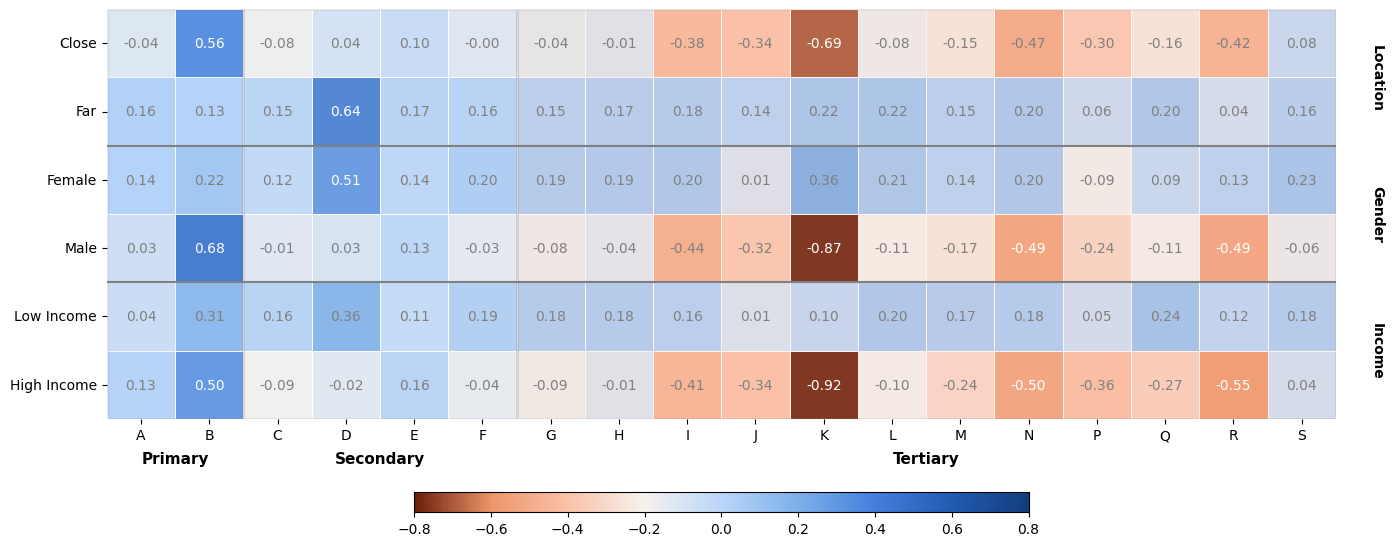

(<Figure size 1400x760 with 2 Axes>, <Axes: >)

In [10]:
plot_industry_heatmap(
    heatmap_df,
    vmin=-0.8, vmax=0.8, vcenter=0,
    filename_stem="heatmap_by_industry_groups",
    row_group_labels={"Location": 0.5, "Gender": 2.5, "Income": 4.5},
    row_separator_every=2,
)

In [11]:
row = [df.loc[df[col] == 1, "work_abs_diff"].mean() for col in industry_cols]

heatmap_mean_df = pd.DataFrame(
    [row],
    index=["All Workers"],
    columns=[col.replace("industry_", "") for col in industry_cols]
)

print(f"Value range in this heatmap: {heatmap_mean_df.values.min():.3f} to {heatmap_mean_df.values.max():.3f}")

Value range in this heatmap: -0.500 to 0.450


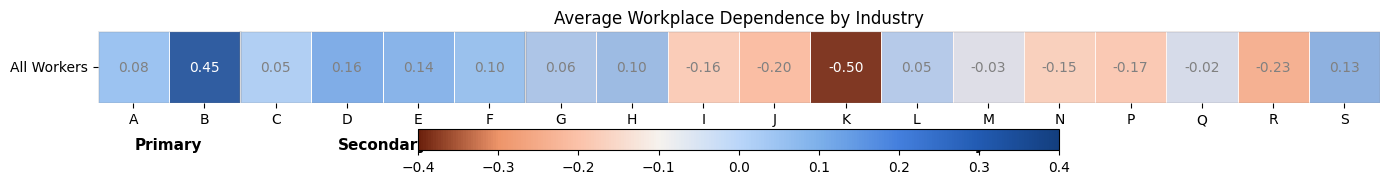

(<Figure size 1400x300 with 2 Axes>,
 <Axes: title={'center': 'Average Workplace Dependence by Industry'}>)

In [13]:
plot_industry_heatmap(
    heatmap_mean_df,
    vmin=-0.4, vmax=0.4, vcenter=0,
    filename_stem="heatmap_by_industry_mean_all",
    title="Average Workplace Dependence by Industry",
)